# Advanced Machine Learning Project



## 1. Data Processing

### Imports

In [9]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns

from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE, SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier

In [10]:
DATASETS_DIR = "datasets"
CSV_FINAL = os.path.join(DATASETS_DIR, "replays_subset_with_time_percentages.csv")

df_model = pd.read_csv(CSV_FINAL, low_memory=False)

# Normaliza target a version agrupada por tier (sin I/II/III ni Division N).
target_source = None
if "max.game.rank" in df_model.columns:
    target_source = "max.game.rank"
elif "max_rank.name" in df_model.columns:
    target_source = "max_rank.name"
else:
    raise KeyError("No se encontro max.game.rank ni max_rank.name para construir el target agrupado")

df_model["max.game.rank"] = (
    df_model[target_source]
    .astype("string")
    .str.replace(r"\s+Division\s+\d+\s*$", "", regex=True)
    .str.replace(r"\s+(I|II|III)\s*$", "", regex=True)
    .str.strip()
)

print("Shape del dataset final:", df_model.shape)
display(df_model.head())

print("\nData type:")
display(df_model.dtypes)

print("\nNull by column:")
display(df_model.isna().sum().sort_values(ascending=False).head(20))

print("\nTarget distribution:")
display(df_model["max.game.rank"].value_counts(dropna=False))

# =========================
# 1. MINIMAL CLEANING FOR MODELING
# =========================
cols_to_drop = [c for c in ["blue.color", "orange.color"] if c in df_model.columns]

if cols_to_drop:
    df_model = df_model.drop(columns=cols_to_drop)

print("\n========================================")
print("Columns removed before modeling")
print("========================================")
print(cols_to_drop if cols_to_drop else "No extra columns were removed")

# =========================
# 2. DEFINE TARGET AND FILTER RARE CLASSES
# =========================
target_col = "max.game.rank"

if target_col not in df_model.columns:
    raise KeyError(f"Target column not found: {target_col}")

original_counts = df_model[target_col].value_counts().sort_values()

print("\n========================================")
print("Original target distribution")
print("========================================")
display(original_counts)

MIN_CLASS_COUNT = 5

valid_classes = original_counts[original_counts >= MIN_CLASS_COUNT].index
removed_classes = original_counts[original_counts < MIN_CLASS_COUNT]

df_model_filtered = df_model[df_model[target_col].isin(valid_classes)].copy()

print("\n========================================")
print("Rare class filtering")
print("========================================")
print(f"Minimum samples required per class: {MIN_CLASS_COUNT}")
print(f"Original number of classes: {df_model[target_col].nunique()}")
print(f"Number of classes after filtering: {df_model_filtered[target_col].nunique()}")
print(f"Original rows: {len(df_model):,}")
print(f"Rows after filtering: {len(df_model_filtered):,}")
print(f"Removed rows: {len(df_model) - len(df_model_filtered):,}")

print("\nRemoved classes:")
display(removed_classes)

print("\nFiltered target distribution:")
filtered_counts = df_model_filtered[target_col].value_counts().sort_values()
display(filtered_counts)

# =========================
# 3. DEFINE X AND y
# =========================
X = df_model_filtered.drop(columns=[target_col])
y = df_model_filtered[target_col]

print("\n========================================")
print("Definition of X and y")
print("========================================")
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# =========================
# 4. IDENTIFY NUMERIC AND CATEGORICAL COLUMNS
# =========================
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()

print("\n========================================")
print("Column types")
print("========================================")
print("Categorical columns:", categorical_cols)
print("Number of categorical columns:", len(categorical_cols))
print("Number of numeric/boolean columns:", len(numeric_cols))

# =========================
# 5. STRATIFIED TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n========================================")
print("Train / Test split")
print("========================================")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nTrain class distribution:")
display(y_train.value_counts().sort_values())

print("\nTest class distribution:")
display(y_test.value_counts().sort_values())

# =========================
# 6. PREPROCESSING
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)

# =========================
# 7. CROSS-VALIDATION AND METRICS
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "mcc": make_scorer(matthews_corrcoef),
}

def build_model_pipeline(model):
    """Create a leakage-safe sklearn Pipeline with the shared preprocessor and the given model."""
    if "preprocessor" not in globals() or not isinstance(preprocessor, ColumnTransformer):
        raise TypeError("'preprocessor' must exist and be a ColumnTransformer before building pipelines.")
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])

print("Leakage-safe pipeline verified: preprocessing is included inside a Pipeline with ColumnTransformer.")

Shape del dataset final: (10000, 107)


,blue.color,blue.stats.ball.possession_time,blue.stats.ball.time_in_side,blue.stats.boost.amount_collected,blue.stats.boost.amount_collected_big,blue.stats.boost.amount_collected_small,blue.stats.boost.amount_overfill,blue.stats.boost.amount_overfill_stolen,blue.stats.boost.amount_stolen,blue.stats.boost.amount_stolen_big,...,orange.stats.positioning.time_behind_ball,orange.stats.positioning.time_defensive_half,orange.stats.positioning.time_defensive_third,orange.stats.positioning.time_infront_ball,orange.stats.positioning.time_neutral_third,orange.stats.positioning.time_offensive_half,orange.stats.positioning.time_offensive_third,overtime,overtime_seconds,server.region
0,blue,44.282927,39.068293,2506,2110,396,289,30,516,369,...,162.912195,128.600000,96.702434,34.546341,57.858537,68.853659,42.887805,False,0.0,USE
1,blue,40.938907,69.038585,3835,2788,1047,588,76,663,427,...,162.025730,106.874598,66.543408,36.411576,82.903543,91.562701,48.987138,False,0.0,USE
2,blue,31.317919,43.644509,5306,3816,1490,403,32,1103,654,...,143.297688,135.034682,97.141618,56.421965,68.057803,64.684971,34.523121,False,0.0,USE
3,blue,36.722500,36.790000,4858,3752,1106,618,251,1148,868,...,150.320000,134.945000,107.170000,47.282500,55.260002,62.655000,35.170000,False,0.0,EU
4,blue,38.622642,49.783019,1281,1006,275,405,38,188,167,...,171.433962,119.905666,83.575472,26.509434,73.584906,78.037736,40.783019,False,0.0,EU



Data type:


blue.color                                        object
blue.stats.ball.possession_time                  float64
blue.stats.ball.time_in_side                     float64
blue.stats.boost.amount_collected                  int64
blue.stats.boost.amount_collected_big              int64
                                                  ...   
orange.stats.positioning.time_offensive_half     float64
orange.stats.positioning.time_offensive_third    float64
overtime                                            bool
overtime_seconds                                 float64
server.region                                     object
Length: 107, dtype: object


Null by column:


...


Definition of X and y
Shape of X: (9997, 104)
Shape of y: (9997,)

Column types
Categorical columns: ['server.region']
Number of categorical columns: 1
Number of numeric/boolean columns: 103

Train / Test split
X_train: (7997, 104)
X_test: (2000, 104)
y_train: (7997,)
y_test: (2000,)

Train class distribution:


max.game.rank
Gold                36
Platinum           156
Diamond            957
Grand Champion    3368
Champion          3480
Name: count, dtype: Int64


Test class distribution:


max.game.rank
Gold                9
Platinum           39
Diamond           239
Grand Champion    842
Champion          871
Name: count, dtype: Int64

Leakage-safe pipeline verified: preprocessing is included inside a Pipeline with ColumnTransformer.


## 2. Imbalance Analysis and Mitigation

Class distribution before balancing


,class_label,percentage
0,Champion,43.516319
1,Grand Champion,42.115793
2,Diamond,11.966988
3,Platinum,1.950732
4,Gold,0.450169


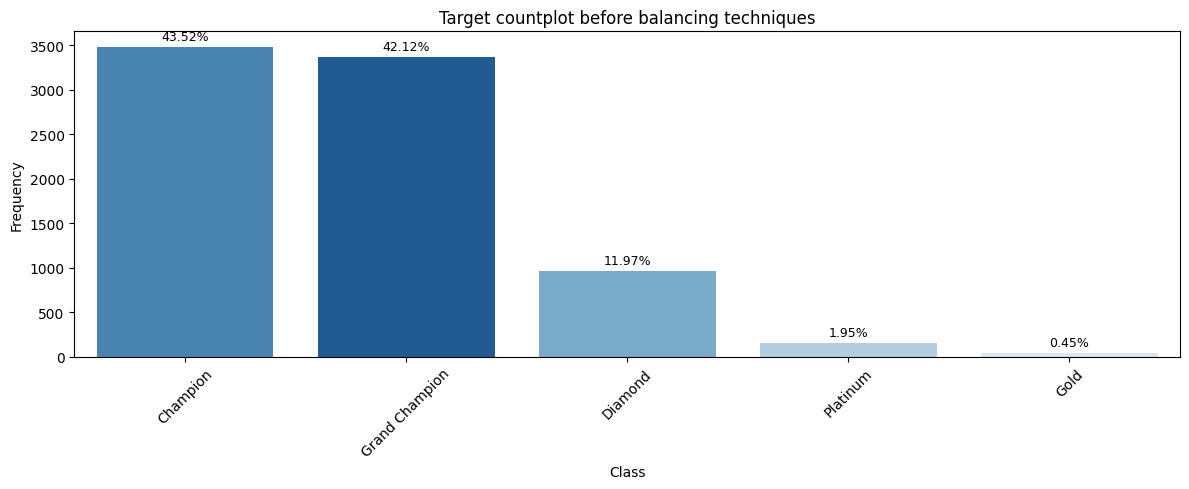

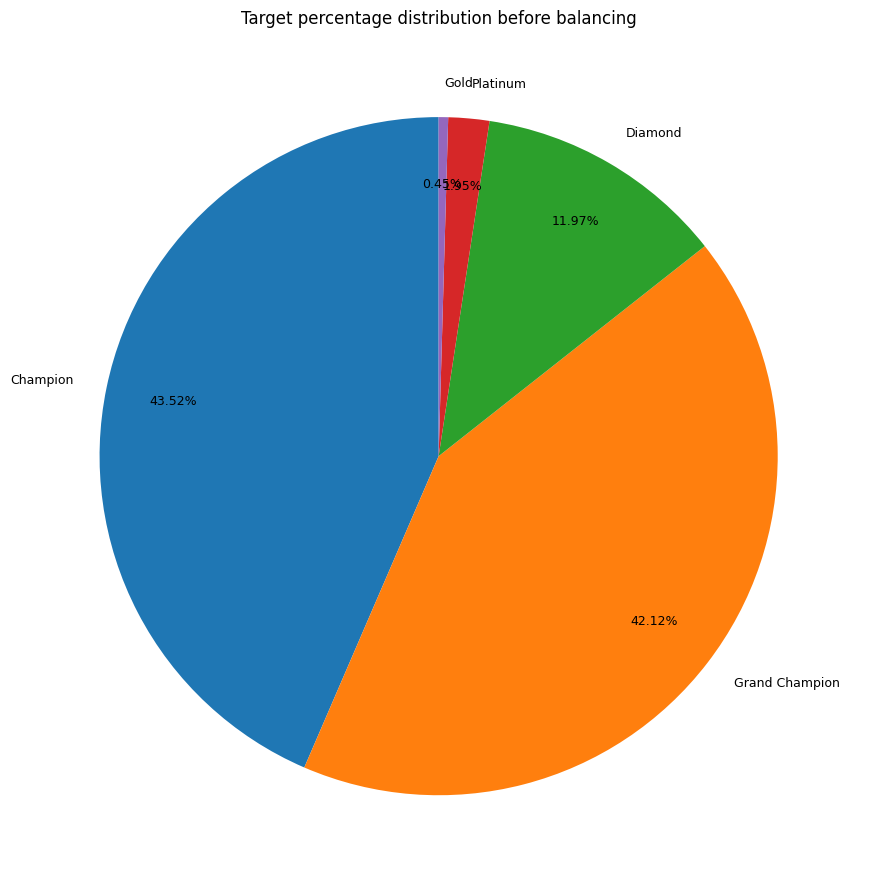

Moderate sampling strategy
Target classes for RandomOverSampler: 2
Target classes for SMOTE: 2
Evaluating imbalance candidate: LR_class_weight_balanced
Evaluating imbalance candidate: RF_class_weight_balanced_subsample
Evaluating imbalance candidate: BalancedRandomForest
Evaluating imbalance candidate: ROS_LR_moderate
Evaluating imbalance candidate: ROS_RF_moderate
Evaluating imbalance candidate: SMOTE_LR_moderate
Evaluating imbalance candidate: SMOTE_RF_moderate

Results of imbalance mitigation methods


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,LR_class_weight_balanced,0.732401,0.006920,0.600694,0.032464,0.737564,0.006221,0.566895,0.026924,0.668339,0.046991,0.582566,0.010288
3,ROS_LR_moderate,0.750282,0.008313,0.589423,0.017906,0.749728,0.008911,0.579025,0.018338,0.645581,0.037987,0.595716,0.013436
5,SMOTE_LR_moderate,0.752032,0.006634,0.585825,0.024464,0.751368,0.007137,0.573832,0.012716,0.638129,0.046155,0.598053,0.010907
6,SMOTE_RF_moderate,0.717019,0.005833,0.537604,0.032254,0.704721,0.005811,0.688859,0.023010,0.506525,0.030046,0.529966,0.010520
4,ROS_RF_moderate,0.721271,0.006381,0.493859,0.052277,0.709126,0.007460,0.646316,0.090229,0.454066,0.041206,0.535201,0.011221
2,BalancedRandomForest,0.639617,0.010942,0.462834,0.015729,0.646967,0.007522,0.436169,0.012250,0.604613,0.020902,0.454089,0.014472
1,RF_class_weight_balanced_subsample,0.714767,0.003892,0.418468,0.018558,0.698535,0.004017,0.587858,0.119836,0.396732,0.010263,0.523356,0.007573


Global comparison (baseline + imbalance)


,model,group,f1_macro_mean,f1_macro_std,mcc_mean,mcc_std,recall_macro_mean,precision_macro_mean,accuracy_mean
0,LogisticRegression,baseline,0.625459,0.018165,0.617254,0.010961,0.613342,0.655946,0.765287
3,Stacking,baseline,0.623777,0.033653,0.621915,0.012930,0.589387,0.690368,0.768664
9,LR_class_weight_balanced,imbalance,0.600694,0.032464,0.582566,0.010288,0.668339,0.566895,0.732401
10,ROS_LR_moderate,imbalance,0.589423,0.017906,0.595716,0.013436,0.645581,0.579025,0.750282
11,SMOTE_LR_moderate,imbalance,0.585825,0.024464,0.598053,0.010907,0.638129,0.573832,0.752032
12,SMOTE_RF_moderate,imbalance,0.537604,0.032254,0.529966,0.010520,0.506525,0.688859,0.717019
4,Bagging,baseline,0.494399,0.038164,0.522631,0.012695,0.457603,0.625613,0.712017
13,ROS_RF_moderate,imbalance,0.493859,0.052277,0.535201,0.011221,0.454066,0.646316,0.721271
5,GradientBoosting,baseline,0.486570,0.031436,0.545642,0.015930,0.468093,0.518514,0.723647
6,Voting,baseline,0.485266,0.017784,0.482745,0.013524,0.460565,0.536780,0.685259


In [11]:
# Visualization of class imbalance before applying any mitigation technique.
if "y_train" not in globals():
    raise NameError("'y_train' does not exist. Run the train/test split cell first.")

class_pct = (
    y_train.value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=False)
    .rename("percentage")
    .reset_index()
)

class_pct.columns = ["class_label", "percentage"]

print("========================================")
print("Class distribution before balancing")
print("========================================")
display(class_pct)

plt.figure(figsize=(12, 5))
ax = sns.countplot(
    x=y_train,
    hue=y_train,
    order=y_train.value_counts().index,
    palette="Blues_r",
    legend=False,
    dodge=False,
)
ax.set_title("Target countplot before balancing techniques")
ax.set_xlabel("Class")
ax.set_ylabel("Frequency")
ax.tick_params(axis="x", rotation=45)

for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(
        f"{height / len(y_train) * 100:.2f}%",
        (patch.get_x() + patch.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 9))
plt.pie(
    class_pct["percentage"],
    labels=class_pct["class_label"],
    autopct="%1.2f%%",
    startangle=90,
    pctdistance=0.8,
    textprops={"fontsize": 9},
)
plt.title("Target percentage distribution before balancing")
plt.tight_layout()
plt.show()

def build_moderate_sampling_strategy(y_train_series: pd.Series) -> dict:
    """Build a moderate target sampling strategy based on the median class frequency."""
    counts = y_train_series.value_counts()
    # Moderate target: bring minority classes up to the median, not to the maximum.
    target = int(counts.median())
    return {cls: target for cls, cnt in counts.items() if cnt < target}


def build_smote_strategy(y_train_series: pd.Series, k_neighbors: int = 3) -> dict:
    """Build a SMOTE strategy only for classes with enough samples for k-neighbors."""
    counts = y_train_series.value_counts()
    target = int(counts.median())
    # SMOTE requires at least k_neighbors + 1 samples per class.
    return {
        cls: target
        for cls, cnt in counts.items()
        if cnt < target and cnt > k_neighbors
    }


def evaluate_cv_models(model_dict: dict, X_data, y_data, cv_obj, scoring_dict) -> pd.DataFrame:
    """Evaluate multiple models with CV and return mean/std metrics in a DataFrame."""
    rows = []

    for name, model in model_dict.items():
        print(f"Evaluating imbalance candidate: {name}")
        cv_scores = cross_validate(
            model,
            X_data,
            y_data,
            cv=cv_obj,
            scoring=scoring_dict,
            n_jobs=1,
            return_train_score=False
        )

        row = {"model": name}
        for metric in scoring_dict.keys():
            row[f"{metric}_mean"] = cv_scores[f"test_{metric}"].mean()
            row[f"{metric}_std"] = cv_scores[f"test_{metric}"].std()

        rows.append(row)

    return pd.DataFrame(rows)

ros_strategy = build_moderate_sampling_strategy(y_train)
smote_strategy = build_smote_strategy(y_train, k_neighbors=3)

print("========================================")
print("Moderate sampling strategy")
print("========================================")
print(f"Target classes for RandomOverSampler: {len(ros_strategy)}")
print(f"Target classes for SMOTE: {len(smote_strategy)}")

imbalance_models = {
    "LR_class_weight_balanced": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42, class_weight="balanced"))
    ]),
    "RF_class_weight_balanced_subsample": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced_subsample"
        ))
    ]),
    "BalancedRandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", BalancedRandomForestClassifier(
            n_estimators=300,
            random_state=42,
            sampling_strategy="auto",
            replacement=False,
            n_jobs=-1
        ))
    ]),
    "ROS_LR_moderate": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42))
    ]),
    "ROS_RF_moderate": ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", RandomOverSampler(sampling_strategy=ros_strategy, random_state=42)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

if smote_strategy:
    imbalance_models["SMOTE_LR_moderate"] = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", SMOTE(sampling_strategy=smote_strategy, k_neighbors=3, random_state=42)),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42))
    ])
    imbalance_models["SMOTE_RF_moderate"] = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", SMOTE(sampling_strategy=smote_strategy, k_neighbors=3, random_state=42)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
else:
    print("[WARN] No classes are eligible for SMOTE with k_neighbors=3 under the moderate strategy.")

imbalance_results_df = evaluate_cv_models(
    imbalance_models,
    X_train,
    y_train,
    cv,
    scoring
).sort_values(["f1_macro_mean", "mcc_mean"], ascending=False)

print("\n========================================")
print("Results of imbalance mitigation methods")
print("========================================")
display(imbalance_results_df)

baseline_blocks = [
    df.copy()
    for name, df in {
        "results_df": globals().get("results_df"),
        "ensemble_results_df": globals().get("ensemble_results_df"),
    }.items()
    if isinstance(df, pd.DataFrame)
]

if isinstance(globals().get("dummy_results"), pd.DataFrame):
    dummy_metrics = {
        metric.replace("test_", ""): {
            f"{metric.replace('test_', '')}_mean": dummy_results[metric].mean(),
            f"{metric.replace('test_', '')}_std": dummy_results[metric].std(),
        }
        for metric in dummy_results.columns
        if metric.startswith("test_")
    }

    baseline_blocks.append(pd.DataFrame([{
        "model": "Dummy_most_frequent",
        **{k: v for d in dummy_metrics.values() for k, v in d.items()}
    }]))

baseline_combined_df = (
    pd.concat(baseline_blocks, ignore_index=True).assign(group="baseline")
    if baseline_blocks else pd.DataFrame()
)

imbalance_tagged_df = imbalance_results_df.copy()
imbalance_tagged_df["group"] = "imbalance"

comparison_df = pd.concat([baseline_combined_df, imbalance_tagged_df], ignore_index=True, sort=False)
comparison_df = comparison_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False)

print("========================================")
print("Global comparison (baseline + imbalance)")
print("========================================")
display(comparison_df[[
    "model", "group",
    "f1_macro_mean", "f1_macro_std",
    "mcc_mean", "mcc_std",
    "recall_macro_mean", "precision_macro_mean", "accuracy_mean"
]].head(20))

## 3. Model Comparison and Hyperparameter Tuning

In [12]:
# =========================
# 8. DUMMY BASELINE
# =========================
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy_scores = cross_validate(
    dummy_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

dummy_results = pd.DataFrame(dummy_scores)

print("\n========================================")
print("Dummy baseline results (CV)")
print("========================================")
display(dummy_results)

print("\nMean scores:")
for metric in scoring.keys():
    print(f"{metric}: {dummy_results[f'test_{metric}'].mean():.4f}")

# =========================
# 10. FIRST COMPARISON OF REAL MODELS
# =========================
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=3000,
        random_state=42
    ),
    "DecisionTree": DecisionTreeClassifier(
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for model_name, model in models.items():
    print("========================================")
    print(f"Training and evaluating: {model_name}")
    print("========================================")

    pipe = build_model_pipeline(model)

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    results.append(row)

results_df = pd.DataFrame(results).sort_values("f1_macro_mean", ascending=False)

print("========================================")
print("Results - first model comparison")
print("========================================")
display(results_df)

# =========================
# ENSEMBLE MODELS COMPARISON
# =========================
ensemble_models = {
    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
    ),
    "Voting": VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=3000, random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ],
        voting="soft"
    ),
    "Stacking": StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=3000, random_state=42)),
            ("dt", DecisionTreeClassifier(random_state=42)),
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ],
        final_estimator=LogisticRegression(max_iter=3000, random_state=42),
        cv=3,
        n_jobs=-1
    )
}

ensemble_results = []

for model_name, model in ensemble_models.items():
    print(f"Evaluating: {model_name}")

    pipe = build_model_pipeline(model)

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    ensemble_results.append(row)

ensemble_results_df = pd.DataFrame(ensemble_results).sort_values(
    "f1_macro_mean", ascending=False
)

print("========================================")
print("Ensemble models comparison")
print("========================================")
display(ensemble_results_df)

# 3) Light hyperparameter search over the top 3 candidates by macro F1
top3_names = imbalance_results_df.head(3)["model"].tolist()
print("Top 3 candidates for tuning:", top3_names)

search_spaces = {
    "LR_class_weight_balanced": {
        "classifier__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    },
    "ROS_LR_moderate": {
        "classifier__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    },
    "SMOTE_LR_moderate": {
        "classifier__C": [0.05, 0.1, 0.3, 1.0, 3.0],
    },
    "RF_class_weight_balanced_subsample": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "ROS_RF_moderate": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "SMOTE_RF_moderate": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
    "BalancedRandomForest": {
        "classifier__n_estimators": [200, 300, 500],
        "classifier__max_depth": [None, 12, 20],
        "classifier__min_samples_leaf": [1, 2, 4],
    },
}

tuning_rows = []
best_tuned_estimators = {}

for name in [n for n in top3_names if n in imbalance_models and n in search_spaces]:
    base_model = imbalance_models[name]
    param_dist = search_spaces[name]

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=min(8, max(map(len, param_dist.values()))),
        scoring="f1_macro",
        cv=3,
        random_state=42,
        n_jobs=1,
        verbose=0,
        refit=True,
    )

    print(f"Tuning: {name}")
    search.fit(X_train, y_train)
    best_tuned_estimators[name] = search.best_estimator_

    tuning_rows.append({
        "model": name,
        "best_cv_f1_macro": search.best_score_,
        "best_params": str(search.best_params_),
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("best_cv_f1_macro", ascending=False)

print("\n========================================")
print("Light tuning results")
print("========================================")
display(tuning_df)


warnings.filterwarnings("ignore", category=UserWarning)

required_objects = ["preprocessor", "X_train", "y_train", "cv", "scoring"]
missing_required = [name for name in required_objects if name not in globals()]
if missing_required:
    raise NameError(
        f"Faltan variables para Section 16: {missing_required}. Ejecuta las secciones anteriores primero."
    )

# XGBoost requiere etiquetas codificadas como 0..K-1 para clasificacion multiclase.
label_encoder_section16 = LabelEncoder()
y_train_section16 = pd.Series(
    label_encoder_section16.fit_transform(y_train),
    index=y_train.index,
    name="target_code",
)

n_classes = int(y_train_section16.nunique())
if n_classes < 2:
    raise ValueError("Se requieren al menos 2 clases para entrenar modelos de clasificacion.")

xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=1,
    reg_lambda=1.0,
    random_state=42,
    tree_method="hist",
    n_jobs=-1,
)

ensemble_models_section16 = {
    "RandomForest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "AdaBoost": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", AdaBoostClassifier(
            n_estimators=300,
            random_state=42
        ))
    ]),
    "XGBoost": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", xgb_base)
    ]),
    "Voting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", VotingClassifier(
            estimators=[
                ("lr", LogisticRegression(max_iter=4000, random_state=42)),
                ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
                ("xgb", clone(xgb_base))
            ],
            voting="soft",
            n_jobs=-1
        ))
    ]),
    "Stacking": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", StackingClassifier(
            estimators=[
                ("lr", LogisticRegression(max_iter=4000, random_state=42)),
                ("rf", RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)),
                ("xgb", clone(xgb_base))
            ],
            final_estimator=LogisticRegression(max_iter=4000, random_state=42),
            cv=3,
            n_jobs=-1
        ))
    ]),
}

ensemble_rows_section16 = []

for model_name, model in ensemble_models_section16.items():
    print(f"Evaluating ensemble model: {model_name}")
    cv_scores = cross_validate(
        model,
        X_train,
        y_train_section16,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )
    row = {"model": model_name}
    for metric in scoring.keys():
        row[f"{metric}_mean"] = cv_scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = cv_scores[f"test_{metric}"].std()
    ensemble_rows_section16.append(row)

ensemble_results_section16_df = pd.DataFrame(ensemble_rows_section16).sort_values(
    ["f1_macro_mean", "mcc_mean"], ascending=False
).reset_index(drop=True)

print("========================================")
print("Section 16 - Ensemble comparison")
print("========================================")
display(ensemble_results_section16_df)


Dummy baseline results (CV)


,fit_time,score_time,test_accuracy,test_f1_macro,test_f1_weighted,test_precision_macro,test_recall_macro,test_mcc
0,0.195298,0.056091,0.435000,0.121254,0.263728,0.087000,0.2,0.0
1,0.224667,0.040311,0.435000,0.121254,0.263728,0.087000,0.2,0.0
2,0.212334,0.042576,0.435272,0.121307,0.264008,0.087054,0.2,0.0
3,0.223654,0.037315,0.435272,0.121307,0.264008,0.087054,0.2,0.0
4,0.240878,0.053968,0.435272,0.121307,0.264008,0.087054,0.2,0.0



Mean scores:
accuracy: 0.4352
f1_macro: 0.1213
f1_weighted: 0.2639
precision_macro: 0.0870
recall_macro: 0.2000
mcc: 0.0000
Training and evaluating: LogisticRegression
Training and evaluating: DecisionTree
Training and evaluating: RandomForest
Results - first model comparison


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,LogisticRegression,0.765287,0.006604,0.625459,0.018165,0.763741,0.006676,0.655946,0.019027,0.613342,0.030955,0.617254,0.010961
2,RandomForest,0.715893,0.004425,0.420625,0.021410,0.701401,0.004819,0.580035,0.124827,0.400288,0.011818,0.525216,0.008024
1,DecisionTree,0.600477,0.006852,0.409185,0.026257,0.600398,0.007043,0.413194,0.029936,0.406346,0.024042,0.353285,0.011827


Evaluating: Bagging
Evaluating: AdaBoost
Evaluating: GradientBoosting
Evaluating: Voting
Evaluating: Stacking
Ensemble models comparison


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
4,Stacking,0.768664,0.007806,0.623777,0.033653,0.766315,0.007788,0.690368,0.029359,0.589387,0.036670,0.621915,0.012930
0,Bagging,0.712017,0.007408,0.494399,0.038164,0.703807,0.007832,0.625613,0.071529,0.457603,0.031887,0.522631,0.012695
2,GradientBoosting,0.723647,0.009484,0.486570,0.031436,0.718841,0.010004,0.518514,0.036380,0.468093,0.028243,0.545642,0.015930
3,Voting,0.685259,0.008190,0.485266,0.017784,0.680403,0.008097,0.536780,0.026000,0.460565,0.016046,0.482745,0.013524
1,AdaBoost,0.652870,0.008224,0.443558,0.010069,0.641109,0.009310,0.452571,0.015433,0.445987,0.011346,0.442815,0.011615


Top 3 candidates for tuning: ['LR_class_weight_balanced', 'ROS_LR_moderate', 'SMOTE_LR_moderate']
Tuning: LR_class_weight_balanced
Tuning: ROS_LR_moderate
Tuning: SMOTE_LR_moderate

Light tuning results


,model,best_cv_f1_macro,best_params
0,LR_class_weight_balanced,0.594888,{'classifier__C': 1.0}
1,ROS_LR_moderate,0.591549,{'classifier__C': 3.0}
2,SMOTE_LR_moderate,0.588074,{'classifier__C': 3.0}


Evaluating ensemble model: RandomForest
Evaluating ensemble model: AdaBoost
Evaluating ensemble model: XGBoost
Evaluating ensemble model: Voting
Evaluating ensemble model: Stacking
Section 16 - Ensemble comparison


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,Stacking,0.768913,0.007997,0.610521,0.052040,0.766436,0.008301,0.657799,0.057262,0.582591,0.048900,0.622260,0.013441
1,Voting,0.757660,0.009758,0.566343,0.024128,0.751749,0.010499,0.690680,0.043207,0.521894,0.024737,0.600380,0.016821
2,XGBoost,0.738778,0.007992,0.496585,0.041380,0.731468,0.008435,0.610805,0.093689,0.463877,0.028618,0.568384,0.013475
3,AdaBoost,0.640113,0.008302,0.447850,0.026099,0.621553,0.013230,0.466723,0.048338,0.457871,0.023272,0.433162,0.006816
4,RandomForest,0.715393,0.003725,0.412028,0.019808,0.700129,0.003825,0.566469,0.134898,0.394990,0.011194,0.524344,0.006858


## 4. Results Discussion

Final training on holdout
Best candidate by CV macro F1: LR_class_weight_balanced

Classification report (holdout test):
                precision    recall  f1-score   support

      Champion     0.7629    0.6613    0.7085       871
       Diamond     0.5215    0.6611    0.5830       239
          Gold     0.4375    0.7778    0.5600         9
Grand Champion     0.8204    0.8302    0.8253       842
      Platinum     0.2703    0.5128    0.3540        39

      accuracy                         0.7300      2000
     macro avg     0.5625    0.6886    0.6062      2000
  weighted avg     0.7472    0.7300    0.7351      2000



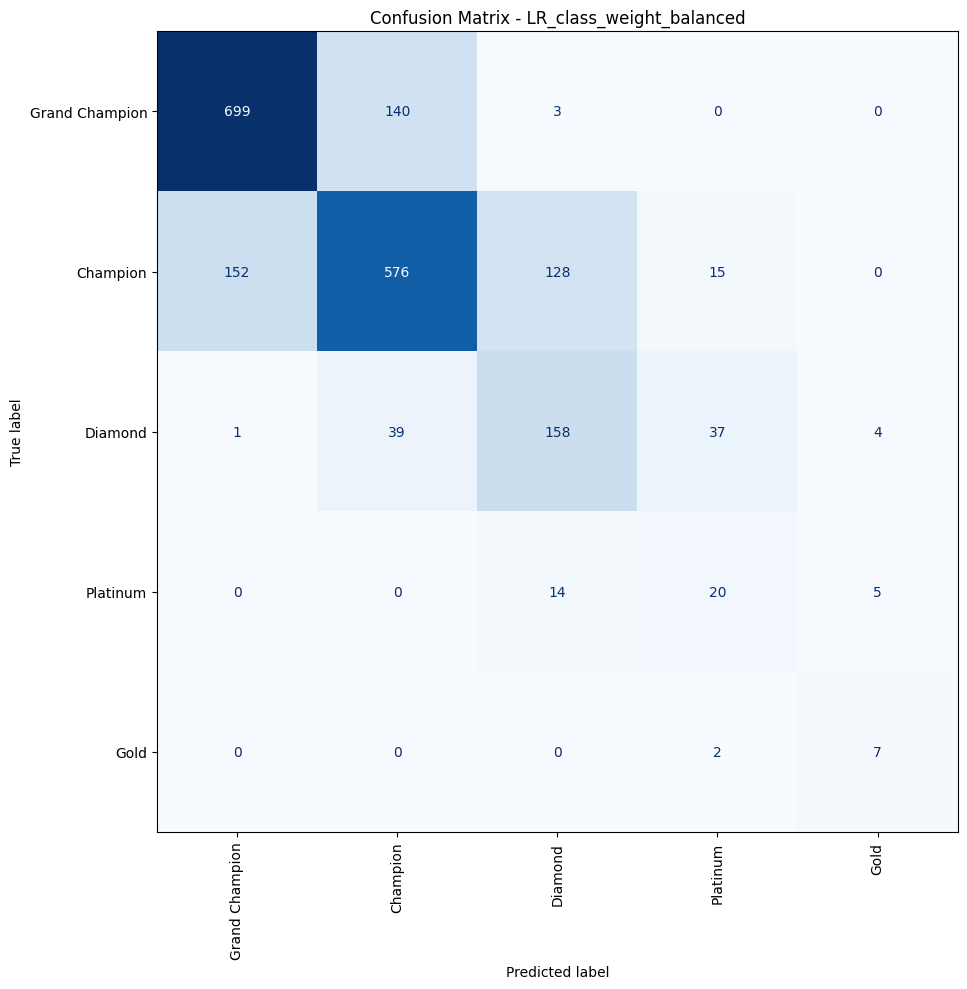

Ordinal report - current model


,metric,value
0,mean_abs_ordinal_error,0.2815
1,pct_exact,0.7300
2,pct_within_1,0.9885
3,pct_within_2,1.0000



SMOTENC candidate ready and evaluated:


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,mcc_mean,mcc_std
0,SMOTENC_LR_moderate,0.74703,0.008023,0.588331,0.010478,0.746001,0.00842,0.57499,0.006905,0.641227,0.029778,0.589654,0.01313


Model selected for calibration: LR_class_weight_balanced
Best global multiplier for minority classes: 1.1
Macro F1 on calibration with threshold adjustment: 0.3400

=== Holdout - calibrated (default argmax) ===
                precision    recall  f1-score   support

      Champion     0.5987    0.7451    0.6639       871
       Diamond     0.0000    0.0000    0.0000       239
          Gold     0.0000    0.0000    0.0000         9
Grand Champion     0.7563    0.8219    0.7877       842
      Platinum     0.0000    0.0000    0.0000        39

      accuracy                         0.6705      2000
     macro avg     0.2710    0.3134    0.2903      2000
  weighted avg     0.5791    0.6705    0.6208      2000


=== Holdout - calibrated + threshold multipliers ===
                precision    recall  f1-score   support

      Champion     0.5993    0.7451    0.6643       871
       Diamond     0.0000    0.0000    0.0000       239
          Gold     0.0000    0.0000    0.0000         9
Gra

...

,scenario,model,task,cv_f1_macro,cv_recall_macro,holdout_accuracy,holdout_f1_macro,holdout_recall_macro,delta_vs_initial_cv_f1_macro,delta_vs_initial_cv_recall_macro,delta_vs_initial_holdout_accuracy,delta_vs_initial_holdout_f1_macro,delta_vs_initial_holdout_recall_macro
0,Initial baseline (exact rank),LogisticRegression,exact_rank,0.625459,0.613342,0.7580,0.660430,0.648889,0.000000,0.000000,0.0000,0.000000,0.000000
1,Current improved (exact rank),LR_class_weight_balanced,exact_rank,0.600694,0.668339,0.7300,0.606152,0.688632,-0.024765,0.054997,-0.0280,-0.054277,0.039744
2,Current improved (tier rank),Tier_ROS_LR,tier_rank,0.589423,0.645581,0.7405,0.602605,0.656959,-0.036036,0.032239,-0.0175,-0.057824,0.008070


Production selector
Objective: exact_rank
Task: exact_rank

Production holdout report (exact rank):
                precision    recall  f1-score   support

      Champion     0.7629    0.6613    0.7085       871
       Diamond     0.5215    0.6611    0.5830       239
          Gold     0.4375    0.7778    0.5600         9
Grand Champion     0.8204    0.8302    0.8253       842
      Platinum     0.2703    0.5128    0.3540        39

      accuracy                         0.7300      2000
     macro avg     0.5625    0.6886    0.6062      2000
  weighted avg     0.7472    0.7300    0.7351      2000


Available function: predict_production(X_new)
Evaluating imbalance candidate: Grouped_Baseline_LR
Evaluating imbalance candidate: Grouped_ROS_LR


,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std
0,Grouped_Baseline_LR,0.764787,0.006226,0.623250,0.020440,0.763234,0.006218,0.654129,0.022651,0.611877,0.032946
1,Grouped_ROS_LR,0.750282,0.008313,0.589423,0.017906,0.749728,0.008911,0.579025,0.018338,0.645581,0.037987



Best grouped model: Grouped_Baseline_LR
Grouped holdout report:
                precision    recall  f1-score   support

      Champion     0.7303    0.7681    0.7487       871
       Diamond     0.6445    0.5690    0.6044       239
          Gold     0.6364    0.7778    0.7000         9
Grand Champion     0.8189    0.8219    0.8204       842
      Platinum     0.7059    0.3077    0.4286        39

      accuracy                         0.7580      2000
     macro avg     0.7072    0.6489    0.6604      2000
  weighted avg     0.7565    0.7580    0.7552      2000

Comparison updated with grouped target (no divisions)


,scenario,model,task,cv_f1_macro,cv_recall_macro,holdout_accuracy,holdout_f1_macro,holdout_recall_macro,delta_vs_initial_cv_f1_macro,delta_vs_initial_cv_recall_macro,delta_vs_initial_holdout_accuracy,delta_vs_initial_holdout_f1_macro,delta_vs_initial_holdout_recall_macro
0,Initial baseline (exact rank),LogisticRegression,exact_rank,0.625459,0.613342,0.7580,0.660430,0.648889,0.000000,0.000000,0.0000,0.000000,0.000000
1,Current improved (exact rank),LR_class_weight_balanced,exact_rank,0.600694,0.668339,0.7300,0.606152,0.688632,-0.024765,0.054997,-0.0280,-0.054277,0.039744
2,Current improved (tier rank),Tier_ROS_LR,tier_rank,0.589423,0.645581,0.7405,0.602605,0.656959,-0.036036,0.032239,-0.0175,-0.057824,0.008070
3,"Current improved (grouped, no divisions)",Grouped_Baseline_LR,grouped_rank,0.623250,0.611877,0.7580,0.660430,0.648889,-0.002209,-0.001465,0.0000,0.000000,0.000000


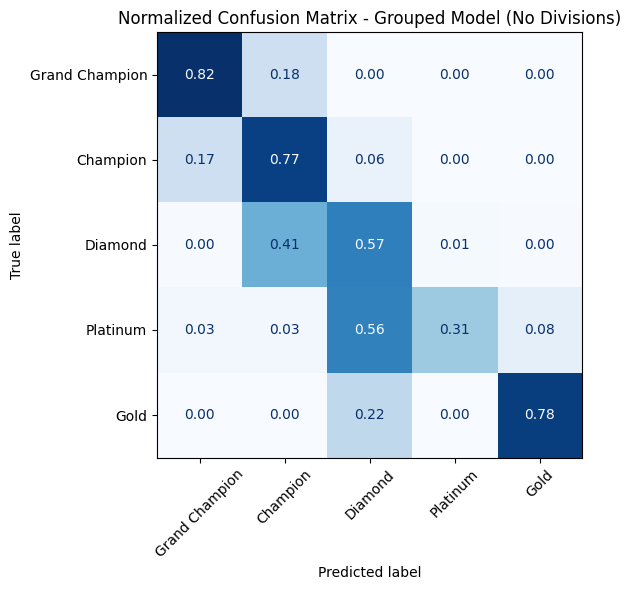

Section 16 - Consolidated metrics table


,model,source,Accuracy,Recall,Precision,F1-macro,MCC
0,LogisticRegression,base_models,0.765287,0.613342,0.655946,0.625459,0.617254
1,Stacking,legacy_ensembles,0.768664,0.589387,0.690368,0.623777,0.621915
2,Stacking,section16_ensembles,0.768913,0.582591,0.657799,0.610521,0.622260
3,LR_class_weight_balanced,imbalance,0.732401,0.668339,0.566895,0.600694,0.582566
4,ROS_LR_moderate,imbalance,0.750282,0.645581,0.579025,0.589423,0.595716
5,SMOTE_LR_moderate,imbalance,0.752032,0.638129,0.573832,0.585825,0.598053
6,Voting,section16_ensembles,0.757660,0.521894,0.690680,0.566343,0.600380
7,SMOTE_RF_moderate,imbalance,0.717019,0.506525,0.688859,0.537604,0.529966
8,XGBoost,section16_ensembles,0.738778,0.463877,0.610805,0.496585,0.568384
9,Bagging,legacy_ensembles,0.712017,0.457603,0.625613,0.494399,0.522631


Models used for confusion matrices


,model,source,Accuracy,Recall,Precision,F1-macro,MCC
0,LogisticRegression,base_models,0.765287,0.613342,0.655946,0.625459,0.617254
1,Stacking,legacy_ensembles,0.768664,0.589387,0.690368,0.623777,0.621915
2,Stacking,section16_ensembles,0.768913,0.582591,0.657799,0.610521,0.622260
3,LR_class_weight_balanced,imbalance,0.732401,0.668339,0.566895,0.600694,0.582566
4,ROS_LR_moderate,imbalance,0.750282,0.645581,0.579025,0.589423,0.595716
5,SMOTE_LR_moderate,imbalance,0.752032,0.638129,0.573832,0.585825,0.598053
6,Voting,section16_ensembles,0.757660,0.521894,0.690680,0.566343,0.600380
7,SMOTE_RF_moderate,imbalance,0.717019,0.506525,0.688859,0.537604,0.529966
9,Bagging,legacy_ensembles,0.712017,0.457603,0.625613,0.494399,0.522631
10,ROS_RF_moderate,imbalance,0.721271,0.454066,0.646316,0.493859,0.535201


Training: LogisticRegression
[base_models]
Training: Stacking
[legacy_ensembles]
Training: Stacking
[section16_ensembles]
Training: LR_class_weight_balanced
[imbalance]
Training: ROS_LR_moderate
[imbalance]
Training: SMOTE_LR_moderate
[imbalance]
Training: Voting
[section16_ensembles]
Training: SMOTE_RF_moderate
[imbalance]
Training: Bagging
[legacy_ensembles]
Training: ROS_RF_moderate
[imbalance]


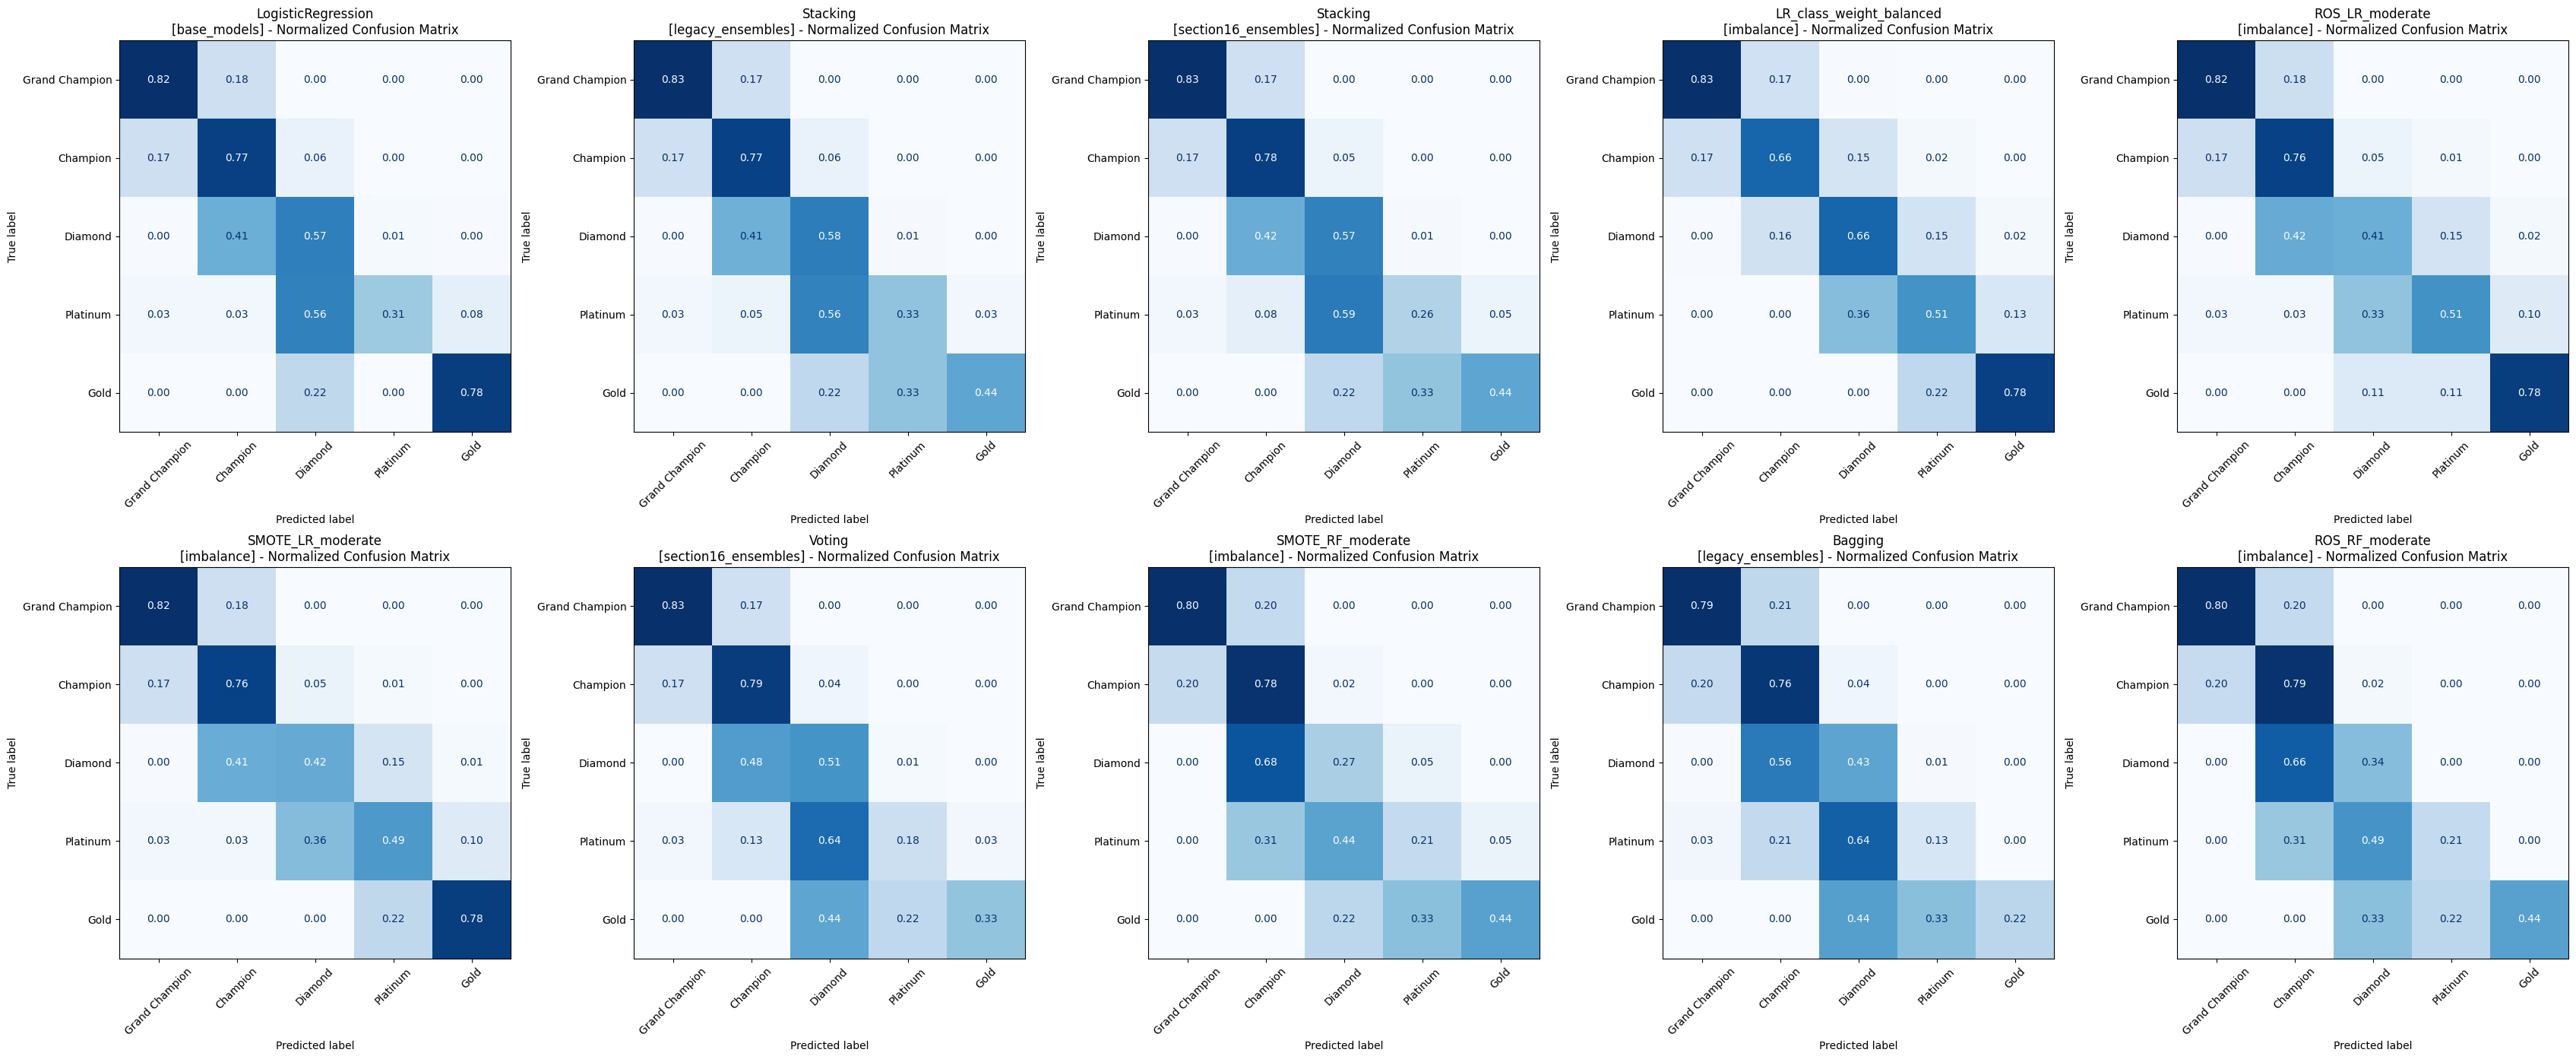

Coefficient matrix by class


,num__blue.stats.ball.possession_time,num__blue.stats.ball.time_in_side,num__blue.stats.boost.amount_collected,num__blue.stats.boost.amount_collected_big,num__blue.stats.boost.amount_collected_small,num__blue.stats.boost.amount_overfill,num__blue.stats.boost.amount_overfill_stolen,num__blue.stats.boost.amount_stolen,num__blue.stats.boost.amount_stolen_big,num__blue.stats.boost.amount_stolen_small,...,cat__server.region_EU,cat__server.region_IND,cat__server.region_JPN,cat__server.region_ME,cat__server.region_OCE,cat__server.region_SAF,cat__server.region_SAM,cat__server.region_USC,cat__server.region_USE,cat__server.region_USW
Champion,0.121591,0.161457,-0.130238,-0.226482,0.151896,-0.647214,0.536567,0.136939,0.285155,-0.191186,...,0.429199,0.599655,0.458530,-0.512697,-1.235116,-0.105944,-0.087607,-0.676967,-0.430025,-0.464004
Diamond,0.062085,0.742310,0.007061,-0.156719,0.433488,-0.531935,0.460435,0.221643,0.325529,-0.050756,...,0.702744,0.041084,1.025552,0.967035,-1.212929,-0.349937,-1.337035,0.435192,0.137851,0.296862
Gold,-0.419064,-1.212125,-0.693297,-0.571246,-0.849559,1.824637,-1.765840,-0.632558,-0.319911,-1.013722,...,-2.792602,-1.650994,0.007379,0.009413,3.690675,0.000954,1.219894,0.660255,-0.371813,-0.225048
Grand Champion,0.184741,0.789349,0.018644,-0.073313,0.254622,-0.524731,0.524177,0.179090,0.343272,-0.193630,...,1.300758,-0.471737,-0.623361,-0.198482,-1.108703,0.454769,1.490547,-0.588432,0.003182,0.039316
Platinum,0.050647,-0.480991,0.797831,1.027760,0.009553,-0.120756,0.244660,0.094886,-0.634046,1.449294,...,0.359901,1.481993,-0.868101,-0.265268,-0.133927,0.000159,-1.285799,0.169951,0.660805,0.352874


Class: Champion
Top positive features


,feature,coefficient
0,num__blue.stats.core.score,1.573284
1,num__orange.stats.movement.count_powerslide,1.081056
2,cat__server.region_ASM,1.072196


Top negative features


...

,feature,coefficient
0,num__duration,-2.105954
1,num__blue.stats.movement.total_distance,-1.998683
2,num__orange.stats.movement.total_distance,-1.376150


Class: Platinum
Top positive features


,feature,coefficient
0,num__duration,2.377642
1,cat__server.region_IND,1.481993
2,num__blue.stats.boost.amount_stolen_small,1.449294


Top negative features


,feature,coefficient
0,num__blue.stats.boost.count_stolen_small,-1.423296
1,num__orange.stats.core.score,-1.353700
2,num__blue.stats.core.score,-1.348884


In [13]:
# =========================================
# FINAL EVALUATION, COMPARISONS, CONSOLIDATION, VISUALIZATION, AND INTERPRETABILITY
# =========================================

# -----------------------------------------
# 0) Best imbalance model on holdout
# -----------------------------------------
best_model_name = imbalance_results_df.iloc[0]["model"]
best_model = imbalance_models[best_model_name]

print("========================================")
print("Final training on holdout")
print("========================================")
print(f"Best candidate by CV macro F1: {best_model_name}")

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("\nClassification report (holdout test):")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

labels_cm = ["Grand Champion", "Champion", "Diamond", "Platinum", "Gold"]

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90,
    labels=labels_cm,
    cmap="Blues",
    ax=ax,
    colorbar=False
)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()


# -----------------------------------------
# 1) Ordinal evaluation helpers
# -----------------------------------------
TIER_ORDER_ORDINAL = {
    "Bronze": 0,
    "Silver": 1,
    "Gold": 2,
    "Platinum": 3,
    "Diamond": 4,
    "Champion": 5,
    "Grand Champion": 6,
    "Supersonic Legend": 7,
}

def rank_to_ordinal(rank: str) -> int | None:
    """Map tier-only rank labels to ordinal integers (no divisions)."""
    if rank is None or pd.isna(rank):
        return None
    return TIER_ORDER_ORDINAL.get(str(rank).strip())

def ordinal_distance_report(y_true: pd.Series, y_pred: pd.Series) -> pd.DataFrame:
    """Compute ordinal-distance quality metrics between true and predicted tier labels."""
    df_eval = pd.DataFrame({"y_true": y_true, "y_pred": y_pred})
    df_eval["true_ord"] = df_eval["y_true"].apply(rank_to_ordinal)
    df_eval["pred_ord"] = df_eval["y_pred"].apply(rank_to_ordinal)
    df_eval = df_eval.dropna(subset=["true_ord", "pred_ord"]).copy()

    if df_eval.empty:
        return pd.DataFrame()

    df_eval["ord_dist"] = (df_eval["true_ord"] - df_eval["pred_ord"]).abs()

    return pd.DataFrame({
        "metric": [
            "mean_abs_ordinal_error",
            "pct_exact",
            "pct_within_1",
            "pct_within_2",
        ],
        "value": [
            df_eval["ord_dist"].mean(),
            (df_eval["ord_dist"] == 0).mean(),
            (df_eval["ord_dist"] <= 1).mean(),
            (df_eval["ord_dist"] <= 2).mean(),
        ],
    })

ordinal_summary_current = ordinal_distance_report(y_test, y_pred)

print("========================================")
print("Ordinal report - current model")
print("========================================")
display(ordinal_summary_current)


# -----------------------------------------
# 2) SMOTENC candidate
# -----------------------------------------
numeric_transformer_smotenc = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer_smotenc = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor_smotenc = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_smotenc, numeric_cols),
        ("cat", categorical_transformer_smotenc, categorical_cols),
    ]
)

n_num = len(numeric_cols)
n_cat = len(categorical_cols)
cat_idx = list(range(n_num, n_num + n_cat))

smotenc_strategy = build_smote_strategy(y_train, k_neighbors=3)

if n_cat > 0 and smotenc_strategy:
    smotenc_lr = ImbPipeline(steps=[
        ("preprocessor", preprocessor_smotenc),
        ("sampler", SMOTENC(
            categorical_features=cat_idx,
            sampling_strategy=smotenc_strategy,
            k_neighbors=3,
            random_state=42,
        )),
        ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
    ])

    smotenc_scores = cross_validate(
        smotenc_lr,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )

    smotenc_row = {
        "model": "SMOTENC_LR_moderate",
        **{
            f"{metric}_{stat}": getattr(smotenc_scores[f"test_{metric}"], stat)()
            for metric in scoring.keys()
            for stat in ["mean", "std"]
        },
    }

    smotenc_results_df = pd.DataFrame([smotenc_row])

    print("\nSMOTENC candidate ready and evaluated:")
    display(smotenc_results_df)
else:
    smotenc_lr = None
    smotenc_results_df = pd.DataFrame()
    print("\n[WARN] SMOTENC was not applied: no categorical features or no valid sampling strategy.")


# -----------------------------------------
# 3) Calibration + threshold multipliers
# -----------------------------------------
if not tuning_df.empty:
    chosen_name = tuning_df.iloc[0]["model"]
    chosen_model = best_tuned_estimators[chosen_name]
else:
    chosen_name = imbalance_results_df.iloc[0]["model"]
    chosen_model = imbalance_models[chosen_name]

print("Model selected for calibration:", chosen_name)

X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

calibrated_model = CalibratedClassifierCV(chosen_model, cv=3, method="sigmoid")
calibrated_model.fit(X_fit, y_fit)

cal_classes = calibrated_model.classes_
cal_proba = calibrated_model.predict_proba(X_cal)

def predict_with_class_multipliers(proba: np.ndarray, classes: np.ndarray, multipliers: dict) -> np.ndarray:
    adj = proba.copy()
    for i, c in enumerate(classes):
        adj[:, i] *= multipliers.get(c, 1.0)
    return classes[adj.argmax(axis=1)]

counts_fit = y_fit.value_counts()
median_count = counts_fit.median()
minority_classes = set(counts_fit[counts_fit < median_count].index)

grid = [0.8, 0.9, 1.0, 1.1, 1.2]
best_f1 = -1.0
best_global_mult = 1.0

for g in grid:
    multipliers = {c: (g if c in minority_classes else 1.0) for c in cal_classes}
    pred = predict_with_class_multipliers(cal_proba, cal_classes, multipliers)
    score = f1_score(y_cal, pred, average="macro")
    if score > best_f1:
        best_f1 = score
        best_global_mult = g

best_multipliers = {c: (best_global_mult if c in minority_classes else 1.0) for c in cal_classes}

print(f"Best global multiplier for minority classes: {best_global_mult}")
print(f"Macro F1 on calibration with threshold adjustment: {best_f1:.4f}")

test_proba = calibrated_model.predict_proba(X_test)
y_test_pred_cal = calibrated_model.predict(X_test)
y_test_pred_thr = predict_with_class_multipliers(test_proba, cal_classes, best_multipliers)

print("\n=== Holdout - calibrated (default argmax) ===")
print(classification_report(y_test, y_test_pred_cal, digits=4, zero_division=0))

print("\n=== Holdout - calibrated + threshold multipliers ===")
print(classification_report(y_test, y_test_pred_thr, digits=4, zero_division=0))

print("\n=== Ordinal report (threshold multipliers) ===")
display(ordinal_distance_report(y_test, y_test_pred_thr))


# -----------------------------------------
# 4) Tier-level grouped experiment
# -----------------------------------------
TIER_ORDER = [
    "Supersonic Legend",
    "Grand Champion",
    "Champion",
    "Diamond",
    "Platinum",
    "Gold",
    "Silver",
    "Bronze",
]

def rank_to_tier(rank: str) -> str:
    """Normalize rank labels to tier-only categories."""
    if rank is None or pd.isna(rank):
        return "Unknown"
    s = str(rank).strip()
    if not s:
        return "Unknown"
    return next((tier for tier in TIER_ORDER if s == tier or s.startswith(f"{tier} ")), s)

y_train_tier = y_train.apply(rank_to_tier)
y_test_tier = y_test.apply(rank_to_tier)

tier_ros_strategy = build_moderate_sampling_strategy(y_train_tier)

tier_model = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(sampling_strategy=tier_ros_strategy, random_state=42)),
    ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
])

tier_cv_scores = cross_validate(
    tier_model,
    X_train,
    y_train_tier,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro",
        "f1_weighted": "f1_weighted",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
    },
    n_jobs=1,
    return_train_score=False,
)

print("========================================")
print("Tier-level experiment (ordinal grouping)")
print("========================================")
print(f"Tier CV macro F1 mean: {tier_cv_scores['test_f1_macro'].mean():.4f}")
print(f"Tier CV macro recall mean: {tier_cv_scores['test_recall_macro'].mean():.4f}")

tier_model.fit(X_train, y_train_tier)
y_tier_pred = tier_model.predict(X_test)

print("\nTier holdout report:")
print(classification_report(y_test_tier, y_tier_pred, digits=4, zero_division=0))


# -----------------------------------------
# 5) Rebuild baseline_combined_df robustly
# -----------------------------------------
baseline_blocks = []

if "results_df" in globals() and isinstance(results_df, pd.DataFrame):
    baseline_blocks.append(results_df.copy())

if "ensemble_results_df" in globals() and isinstance(ensemble_results_df, pd.DataFrame):
    baseline_blocks.append(ensemble_results_df.copy())

if "dummy_results" in globals() and isinstance(dummy_results, pd.DataFrame):
    baseline_blocks.append(pd.DataFrame([{
        "model": "Dummy_most_frequent",
        "accuracy_mean": dummy_results["test_accuracy"].mean(),
        "accuracy_std": dummy_results["test_accuracy"].std(),
        "f1_macro_mean": dummy_results["test_f1_macro"].mean(),
        "f1_macro_std": dummy_results["test_f1_macro"].std(),
        "f1_weighted_mean": dummy_results["test_f1_weighted"].mean(),
        "f1_weighted_std": dummy_results["test_f1_weighted"].std(),
        "precision_macro_mean": dummy_results["test_precision_macro"].mean(),
        "precision_macro_std": dummy_results["test_precision_macro"].std(),
        "recall_macro_mean": dummy_results["test_recall_macro"].mean(),
        "recall_macro_std": dummy_results["test_recall_macro"].std(),
        "mcc_mean": dummy_results["test_mcc"].mean(),
        "mcc_std": dummy_results["test_mcc"].std(),
    }]))

if not baseline_blocks:
    raise ValueError("No baseline result tables are available to build baseline_combined_df.")

baseline_combined_df = pd.concat(baseline_blocks, ignore_index=True)
baseline_combined_df["group"] = "baseline"


# -----------------------------------------
# 6) Initial vs current comparison
# -----------------------------------------
baseline_only = baseline_combined_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False).copy()
baseline_best_name = baseline_only.iloc[0]["model"]

def get_baseline_model_by_name(name: str):
    if name == "Dummy_most_frequent":
        return dummy_model
    if "results_df" in globals() and "model" in results_df.columns and name in set(results_df["model"]):
        return build_model_pipeline(models[name])
    if "ensemble_results_df" in globals() and "model" in ensemble_results_df.columns and name in set(ensemble_results_df["model"]):
        return build_model_pipeline(ensemble_models[name])
    raise KeyError(f"Could not map baseline model: {name}")

baseline_best_model = get_baseline_model_by_name(baseline_best_name)
baseline_best_model.fit(X_train, y_train)
y_pred_baseline = baseline_best_model.predict(X_test)

exact_best_row = imbalance_results_df.sort_values(["f1_macro_mean", "mcc_mean"], ascending=False).iloc[0]
exact_best_name = exact_best_row["model"]
exact_best_model = imbalance_models[exact_best_name]
exact_best_model.fit(X_train, y_train)
y_pred_exact_current = exact_best_model.predict(X_test)

tier_model.fit(X_train, y_train_tier)
y_pred_tier_current = tier_model.predict(X_test)

comparison_rows = [
    {
        "scenario": "Initial baseline (exact rank)",
        "model": baseline_best_name,
        "task": "exact_rank",
        "cv_f1_macro": float(baseline_only.iloc[0]["f1_macro_mean"]),
        "cv_recall_macro": float(baseline_only.iloc[0]["recall_macro_mean"]),
        "holdout_accuracy": accuracy_score(y_test, y_pred_baseline),
        "holdout_f1_macro": f1_score(y_test, y_pred_baseline, average="macro"),
        "holdout_recall_macro": recall_score(y_test, y_pred_baseline, average="macro"),
    },
    {
        "scenario": "Current improved (exact rank)",
        "model": exact_best_name,
        "task": "exact_rank",
        "cv_f1_macro": float(exact_best_row["f1_macro_mean"]),
        "cv_recall_macro": float(exact_best_row["recall_macro_mean"]),
        "holdout_accuracy": accuracy_score(y_test, y_pred_exact_current),
        "holdout_f1_macro": f1_score(y_test, y_pred_exact_current, average="macro"),
        "holdout_recall_macro": recall_score(y_test, y_pred_exact_current, average="macro"),
    },
    {
        "scenario": "Current improved (tier rank)",
        "model": "Tier_ROS_LR",
        "task": "tier_rank",
        "cv_f1_macro": float(tier_cv_scores["test_f1_macro"].mean()),
        "cv_recall_macro": float(tier_cv_scores["test_recall_macro"].mean()),
        "holdout_accuracy": accuracy_score(y_test_tier, y_pred_tier_current),
        "holdout_f1_macro": f1_score(y_test_tier, y_pred_tier_current, average="macro"),
        "holdout_recall_macro": recall_score(y_test_tier, y_pred_tier_current, average="macro"),
    },
]

metrics_comparison_df = pd.DataFrame(comparison_rows)

baseline_ref = metrics_comparison_df.iloc[0]
for col in ["cv_f1_macro", "cv_recall_macro", "holdout_accuracy", "holdout_f1_macro", "holdout_recall_macro"]:
    metrics_comparison_df[f"delta_vs_initial_{col}"] = metrics_comparison_df[col] - baseline_ref[col]

print("========================================")
print("Initial vs current comparison")
print("========================================")
display(metrics_comparison_df)


# -----------------------------------------
# 7) Production selector
# -----------------------------------------
DEPLOY_OBJECTIVE = "exact_rank"

if DEPLOY_OBJECTIVE == "exact_rank":
    production_model = exact_best_model
    production_task = "exact_rank"
elif DEPLOY_OBJECTIVE == "tier_rank":
    production_model = tier_model
    production_task = "tier_rank"
else:
    raise ValueError("DEPLOY_OBJECTIVE must be 'exact_rank' or 'tier_rank'")

print("========================================")
print("Production selector")
print("========================================")
print(f"Objective: {DEPLOY_OBJECTIVE}")
print(f"Task: {production_task}")

final_pred = production_model.predict(X_test)

if production_task == "exact_rank":
    print("\nProduction holdout report (exact rank):")
    print(classification_report(y_test, final_pred, digits=4, zero_division=0))
else:
    print("\nProduction holdout report (tier rank):")
    print(classification_report(y_test_tier, final_pred, digits=4, zero_division=0))

def predict_production(X_new: pd.DataFrame) -> pd.Series:
    """Run production inference and return predictions aligned with the input index."""
    y_hat = production_model.predict(X_new)
    return pd.Series(y_hat, index=X_new.index, name="prediction")

print("\nAvailable function: predict_production(X_new)")


# -----------------------------------------
# 8) Grouped experiment (no divisions)
# -----------------------------------------
y_group = y.apply(rank_to_tier)

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X,
    y_group,
    test_size=0.2,
    random_state=42,
    stratify=y_group,
)

group_scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
}

cv_group = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

group_baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
])

group_ros_strategy = build_moderate_sampling_strategy(y_train_g)
group_ros = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(sampling_strategy=group_ros_strategy, random_state=42)),
    ("classifier", LogisticRegression(max_iter=4000, random_state=42)),
])

group_models = {
    "Grouped_Baseline_LR": group_baseline,
    "Grouped_ROS_LR": group_ros,
}

group_results_df = evaluate_cv_models(
    group_models,
    X_train_g,
    y_train_g,
    cv_group,
    group_scoring
).sort_values("f1_macro_mean", ascending=False)

display(group_results_df)

best_group_model_name = group_results_df.iloc[0]["model"]
best_group_model = group_models[best_group_model_name]
best_group_model.fit(X_train_g, y_train_g)
y_pred_group = best_group_model.predict(X_test_g)

print("\nBest grouped model:", best_group_model_name)
print("Grouped holdout report:")
print(classification_report(y_test_g, y_pred_group, digits=4, zero_division=0))

grouped_row = {
    "scenario": "Current improved (grouped, no divisions)",
    "model": best_group_model_name,
    "task": "grouped_rank",
    "cv_f1_macro": float(group_results_df.iloc[0]["f1_macro_mean"]),
    "cv_recall_macro": float(group_results_df.iloc[0]["recall_macro_mean"]),
    "holdout_accuracy": accuracy_score(y_test_g, y_pred_group),
    "holdout_f1_macro": f1_score(y_test_g, y_pred_group, average="macro"),
    "holdout_recall_macro": recall_score(y_test_g, y_pred_group, average="macro"),
}

metrics_comparison_plus_grouped_df = pd.concat(
    [metrics_comparison_df, pd.DataFrame([grouped_row])],
    ignore_index=True,
    sort=False,
)

baseline_ref = metrics_comparison_plus_grouped_df.iloc[0]
for col in ["cv_f1_macro", "cv_recall_macro", "holdout_accuracy", "holdout_f1_macro", "holdout_recall_macro"]:
    metrics_comparison_plus_grouped_df[f"delta_vs_initial_{col}"] = (
        metrics_comparison_plus_grouped_df[col] - baseline_ref[col]
    )

print("========================================")
print("Comparison updated with grouped target (no divisions)")
print("========================================")
display(metrics_comparison_plus_grouped_df)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_g,
    y_pred_group,
    labels=labels_cm,
    normalize="true",
    xticks_rotation=45,
    cmap="Blues",
    values_format=".2f",
    colorbar=False,
    ax=ax,
)
ax.set_title("Normalized Confusion Matrix - Grouped Model (No Divisions)")
plt.tight_layout()
plt.show()


# -----------------------------------------
# 9) Consolidated metrics table
# -----------------------------------------
def _standardize_results_for_comparison(df_in: pd.DataFrame, source_name: str) -> pd.DataFrame:
    if df_in is None or df_in.empty:
        return pd.DataFrame()

    df = df_in.copy()

    if "model" not in df.columns:
        df["model"] = df["experiment"] if "experiment" in df.columns else source_name

    required_cols = [
        "accuracy_mean",
        "recall_macro_mean",
        "precision_macro_mean",
        "f1_macro_mean",
        "mcc_mean",
    ]
    for col in required_cols:
        if col not in df.columns:
            df[col] = np.nan

    out = df[[
        "model",
        "accuracy_mean",
        "recall_macro_mean",
        "precision_macro_mean",
        "f1_macro_mean",
        "mcc_mean",
    ]].copy()
    out["source"] = source_name
    return out

comparison_blocks = [
    _standardize_results_for_comparison(df, source)
    for df, source in [
        (globals().get("results_df"), "base_models"),
        (globals().get("ensemble_results_df"), "legacy_ensembles"),
        (globals().get("imbalance_results_df"), "imbalance"),
        (globals().get("ensemble_results_section16_df"), "section16_ensembles"),
        (globals().get("xgb_optuna_results_df"), "optuna_pruned"),
    ]
    if df is not None
]

if not comparison_blocks:
    raise ValueError("No results are available to consolidate.")

metrics_consolidated_df = (
    pd.concat(comparison_blocks, ignore_index=True)
    .dropna(subset=["f1_macro_mean"])
    .sort_values(["f1_macro_mean", "mcc_mean"], ascending=False)
    .reset_index(drop=True)
    .rename(columns={
        "accuracy_mean": "Accuracy",
        "recall_macro_mean": "Recall",
        "precision_macro_mean": "Precision",
        "f1_macro_mean": "F1-macro",
        "mcc_mean": "MCC",
    })
)

print("========================================")
print("Section 16 - Consolidated metrics table")
print("========================================")
display(metrics_consolidated_df[[
    "model",
    "source",
    "Accuracy",
    "Recall",
    "Precision",
    "F1-macro",
    "MCC",
]])


# -----------------------------------------
# 10) Normalized confusion matrices for top models
# -----------------------------------------
def plot_confusion_matrix_normalized(y_true, y_pred, title, labels=None, ax=None, cmap="Blues"):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true=y_true,
        y_pred=y_pred,
        labels=labels,
        normalize="true",
        cmap=cmap,
        xticks_rotation=45,
        values_format=".2f",
        colorbar=False,
        ax=ax,
    )
    disp.ax_.set_title(title)
    return disp

top10_df = (
    metrics_consolidated_df
    .loc[~metrics_consolidated_df["model"].isin(["XGBoost", "XGBoost_OptunaPruned"])]
    .sort_values(["F1-macro", "MCC"], ascending=False)
    .head(10)
)

print("========================================")
print("Models used for confusion matrices")
print("========================================")
display(top10_df[["model", "source", "Accuracy", "Recall", "Precision", "F1-macro", "MCC"]])

def get_model_object(model_name, source_name):
    if source_name == "base_models":
        if model_name in models:
            return models[model_name]
        return None

    if source_name == "legacy_ensembles":
        if model_name == "Stacking" and "stacking_model" in globals():
            return stacking_model
        if model_name in ensemble_models:
            return ensemble_models[model_name]
        return None

    if source_name == "section16_ensembles":
        if model_name == "XGBoost":
            return None
        if model_name in ensemble_models_section16:
            return ensemble_models_section16[model_name]
        return None

    if source_name == "imbalance":
        if model_name == "SMOTE_LR_moderate" and "smote_lr" in globals():
            return smote_lr
        if model_name in imbalance_models:
            return imbalance_models[model_name]
        return None

    if source_name == "optuna_pruned" and model_name == "XGBoost_OptunaPruned":
        return None

    return None

def ensure_pipeline(model_obj):
    cls_name = model_obj.__class__.__name__.lower()
    module_name = model_obj.__class__.__module__.lower()
    return clone(model_obj) if "pipeline" in cls_name or "pipeline" in module_name else build_model_pipeline(clone(model_obj))

predictions = {}
missing_models = []

for _, row in top10_df.iterrows():
    model_name, source_name = row["model"], row["source"]
    model_obj = get_model_object(model_name, source_name)

    if model_obj is None:
        missing_models.append((model_name, source_name))
        continue

    fitted_model = ensure_pipeline(model_obj)
    display_name = f"{model_name}\n[{source_name}]"
    print(f"Training: {display_name}")
    fitted_model.fit(X_train, y_train)
    predictions[display_name] = fitted_model.predict(X_test)

if missing_models:
    print("\nModels that could not be resolved:")
    for item in missing_models:
        print(item)

fig, axes = plt.subplots(2, 5, figsize=(34, 14))
axes = axes.ravel()

for ax, (model_name, y_pred_plot) in zip(axes, predictions.items()):
    plot_confusion_matrix_normalized(
        y_true=y_test,
        y_pred=y_pred_plot,
        title=f"{model_name} - Normalized Confusion Matrix",
        labels=labels_cm,
        ax=ax,
    )

for ax in axes[len(predictions):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


# -----------------------------------------
# 11) Class-specific feature importance for LR_class_weight_balanced
# -----------------------------------------
best_model_name = "LR_class_weight_balanced"

if "imbalance_models" not in globals():
    raise NameError("imbalance_models is not defined. Run the imbalance section first.")

if best_model_name not in imbalance_models:
    raise KeyError(f"{best_model_name} was not found in imbalance_models.")

best_model = imbalance_models[best_model_name]
best_model.fit(X_train, y_train)

preprocessor_fitted = best_model.named_steps["preprocessor"]
classifier_fitted = best_model.named_steps["classifier"]

feature_names = preprocessor_fitted.get_feature_names_out()
class_names = classifier_fitted.classes_
coef_matrix = classifier_fitted.coef_

coef_df = pd.DataFrame(coef_matrix, index=class_names, columns=feature_names)

print("========================================")
print("Coefficient matrix by class")
print("========================================")
display(coef_df)

top_n = 3

for class_name in class_names:
    class_coefs = coef_df.loc[class_name].sort_values(ascending=False)

    top_positive = class_coefs.head(top_n).reset_index()
    top_positive.columns = ["feature", "coefficient"]

    top_negative = class_coefs.tail(top_n).sort_values(ascending=True).reset_index()
    top_negative.columns = ["feature", "coefficient"]

    print("========================================")
    print(f"Class: {class_name}")
    print("Top positive features")
    print("========================================")
    display(top_positive)

    print("Top negative features")
    display(top_negative)

plt.show()